Unemployment Rate Analysis During Covid-19 Using Python

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install requests

Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving archive (2).zip to archive (2).zip
User uploaded file "archive (2).zip" with length 16335 bytes


In [ ]:
import os

print(os.listdir('unemployment_data'))

['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [ ]:
import zipfile
import pandas as pd

In [ ]:
# Extract ZIP file
with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("unemployment_data")

In [ ]:
# Load CSV files
df1 = pd.read_csv("unemployment_data/Unemployment in India.csv")
df2 = pd.read_csv("unemployment_data/Unemployment_Rate_upto_11_2020.csv")

In [ ]:
# Display first rows
print(df1.head())
print(df2.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0 

Understand the Dataset

In [ ]:
print(df1.info())
print(df1.describe())
print(df1.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std          

Data Cleaning

In [ ]:
print(df1.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [ ]:
df1 = df1.dropna()

In [ ]:
df1.columns = [
    'States',
    'Date',
    'Frequency',
    'Estimated Unemployment Rate',
    'Estimated Employed',
    'Estimated Labour Participation Rate',
    'Region'
]

Convert Date Column

In [ ]:
df1['Date'] = pd.to_datetime(df1['Date'])

/tmp/ipykernel_2871/1148610173.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


Exploratory Data Analysis (EDA)

In [ ]:
print(df1.shape)

(740, 7)


Unique States

In [ ]:
print(df1['States'].unique())

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Chandigarh']


Average Unemployment Rate

In [ ]:
avg_rate = df1['Estimated Unemployment Rate'].mean()
print("Average Unemployment Rate:", avg_rate)

Average Unemployment Rate: 11.787945945945946


Data Visualization

Unemployment Rate Distribution

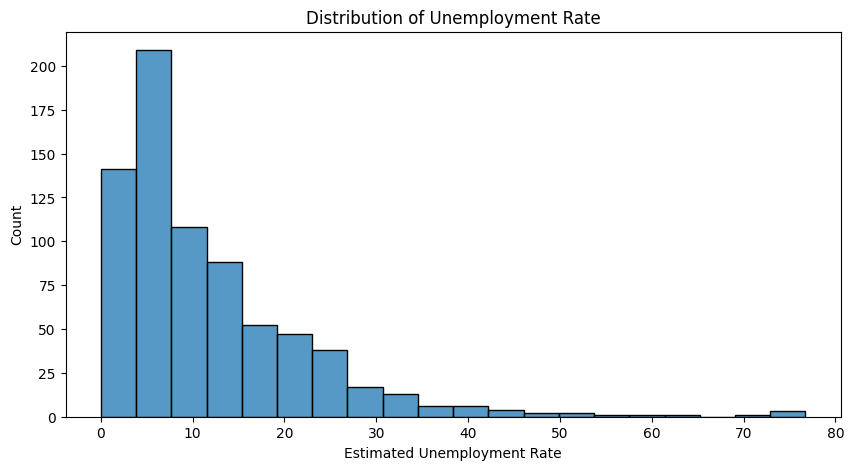

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df1['Estimated Unemployment Rate'], bins=20)
plt.title('Distribution of Unemployment Rate')
plt.show()

Unemployment Rate by State

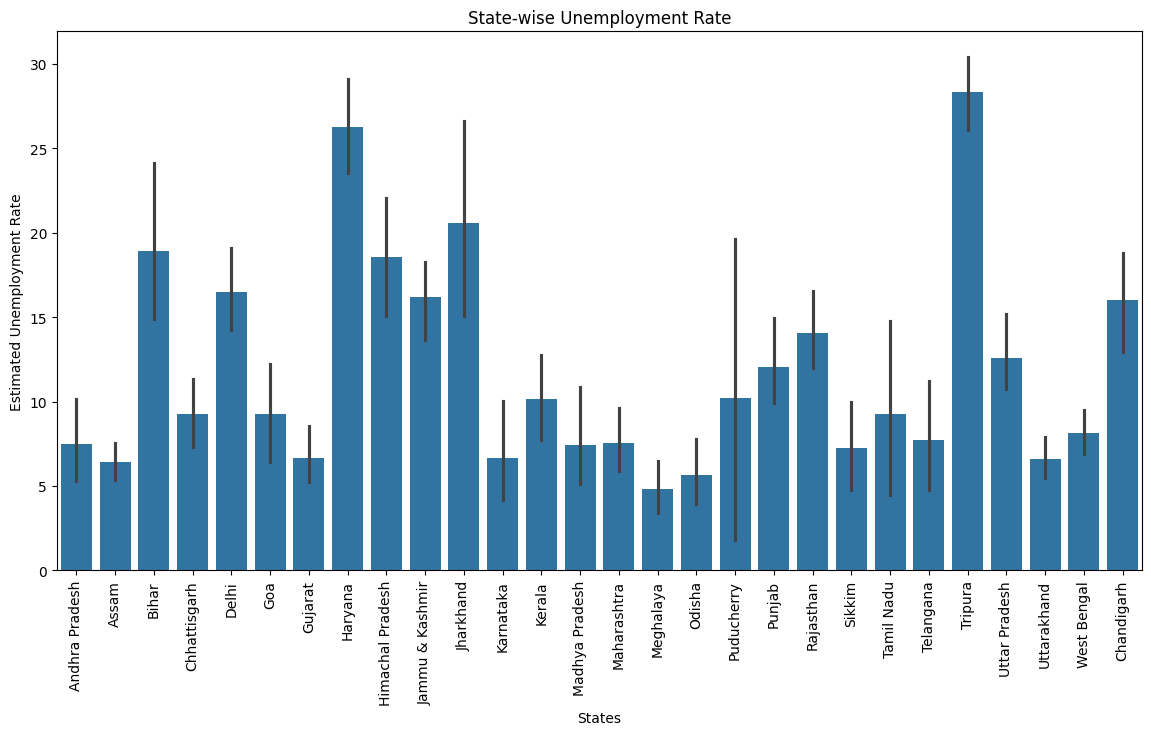

In [ ]:
plt.figure(figsize=(14,7))
sns.barplot(
    x='States',
    y='Estimated Unemployment Rate',
    data=df1
)
plt.xticks(rotation=90)
plt.title('State-wise Unemployment Rate')
plt.show()

Covid-19 Impact Over Time

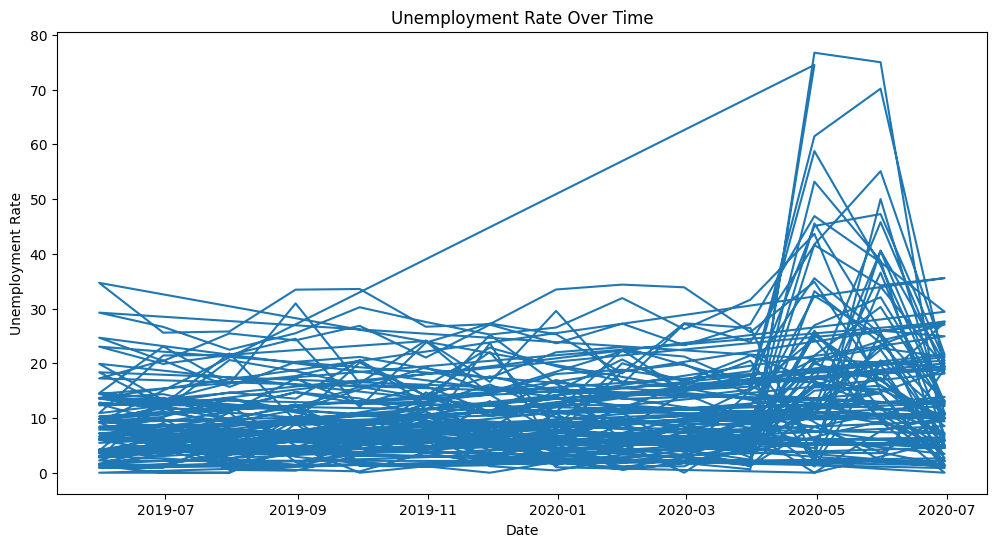

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(
    df1['Date'],
    df1['Estimated Unemployment Rate']
)
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.show()

Heatmap Correlation

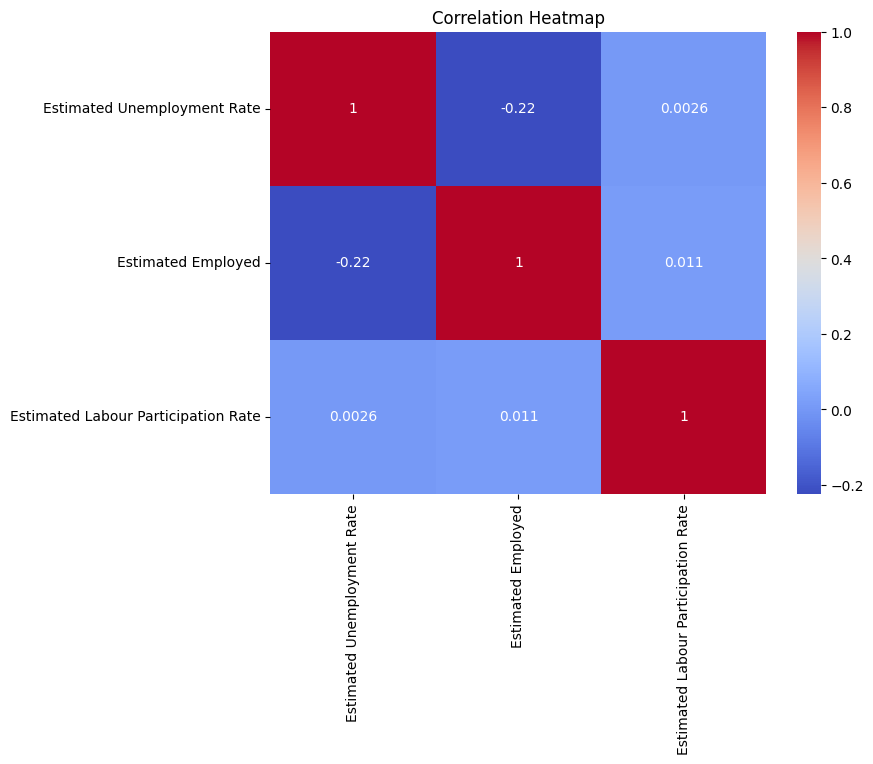

In [ ]:
corr = df1.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Analyze Covid-19 Effect

Data During Covid-19

In [ ]:
covid_data = df1[
    df1['Date'] >= '2020-03-01'
]

print(covid_data.head())

            States       Date Frequency  Estimated Unemployment Rate  \
10  Andhra Pradesh 2020-03-31   Monthly                         4.06   
11  Andhra Pradesh 2020-04-30   Monthly                        16.29   
12  Andhra Pradesh 2020-05-31   Monthly                        14.46   
13  Andhra Pradesh 2020-06-30   Monthly                         0.85   
23           Assam 2020-03-31   Monthly                         3.77   

    Estimated Employed  Estimated Labour Participation Rate Region  
10          11359660.0                                40.66  Rural  
11           8792827.0                                36.03  Rural  
12           9526902.0                                38.16  Rural  
13          15572975.0                                53.76  Rural  
23           9878742.0                                47.05  Rural  


Average Unemployment During Covid

In [ ]:
print(covid_data['Estimated Unemployment Rate'].mean())

17.774362745098042


Top 10 States with Highest Unemployment

In [ ]:
top_states = df1.groupby('States')[
    'Estimated Unemployment Rate'
].mean().sort_values(ascending=False).head(10)

print(top_states)

States
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate, dtype: float64


Visualization

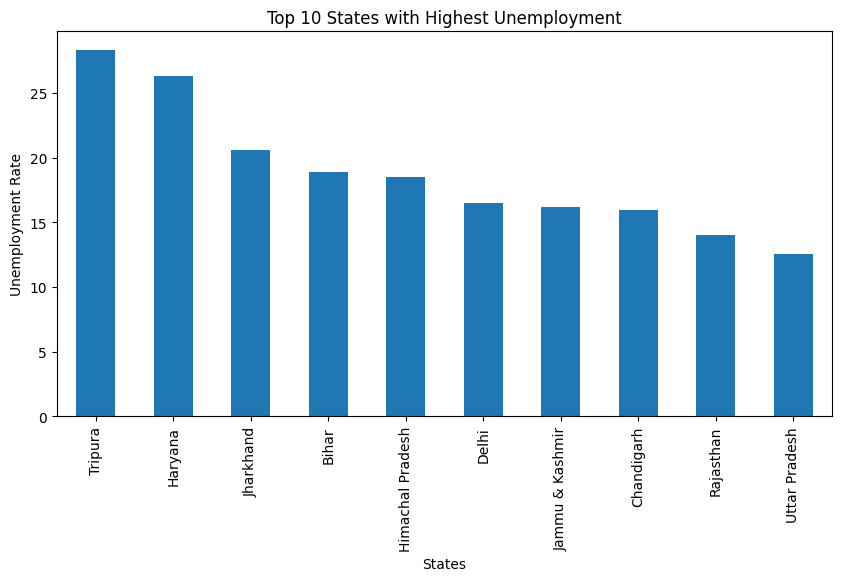

In [ ]:
plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title('Top 10 States with Highest Unemployment')
plt.ylabel('Unemployment Rate')
plt.show()

# Conclusion
Covid-19 caused a major increase in unemployment.
Some states were more affected than others.
Labour participation rate decreased during lockdown periods.
Data visualization clearly shows unemployment spikes in 2020.